In [ ]:
#  Install & imports
!pip install --quiet torch numpy pandas matplotlib scikit-learn tqdm

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from google.colab import files
from tqdm import trange

import random
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


In [ ]:
#  Upload data files
print("Please upload: PTDF.csv, demands_loadbus.csv, cost_coeffs.csv, targets.csv, line_limits.csv")
_ = files.upload()

# Read CSVs
PTDF = pd.read_csv("PTDF.csv", header=None).values.astype(float)         # shape (num_lines, num_buses)
demands_data = pd.read_csv("demands_loadbus.csv", header=None).values.astype(float)  # (N_samples, num_load_buses) : each row is a demand scenario for the load buses
cost_coeffs = pd.read_csv("cost_coeffs.csv", header=None).values.astype(float)      # (num_gens, 2) columns a,b
targets = pd.read_csv("targets.csv", header=None).values.astype(float)              # (N_samples, target_dim=23) : each row is the target for the corresponding demand scenario in demands_data
line_limits_arr = pd.read_csv("line_limits.csv", header=None).values.flatten().astype(float)

num_lines, num_buses = PTDF.shape
print("num_lines:", num_lines, "num_buses:", num_buses)
print("demands shape:", demands_data.shape)
print("cost_coeffs shape:", cost_coeffs.shape)
print("targets shape:", targets.shape)


Please upload: PTDF.csv, demands_loadbus.csv, cost_coeffs.csv, targets.csv, line_limits.csv


Saving cost_coeffs.csv to cost_coeffs.csv
Saving demands_loadbus.csv to demands_loadbus.csv
Saving line_limits.csv to line_limits.csv
Saving PTDF.csv to PTDF.csv
Saving targets.csv to targets.csv
num_lines: 46 num_buses: 39
demands shape: (9979, 21)
cost_coeffs shape: (10, 3)
targets shape: (9979, 23)


In [ ]:
# Define generator/load buses and parameters

load_bus = np.array([1,3,4,7,8,9,12,15,16,18,20,21,23,24,25,26,27,28,29,31,39]) - 1 #From matpower case file of IEEE 39-bus system
generator_bus_indices = np.array([30,31,32,33,34,35,36,37,38,39]) - 1 #From matpower case file of IEEE 39-bus system

num_gens = generator_bus_indices.size
print("num_gens:", num_gens)

# Generator limits (pmin, pmax)
pmax = np.array([1040, 646, 725, 652, 508, 687, 580, 564, 865, 1100], dtype=float) #From matpower case file of IEEE 39-bus system
pmin = np.zeros_like(pmax)

line_limits = line_limits_arr.astype(float)

print("Generators:", num_gens)
print("Lines:", num_lines)


num_gens: 10
Generators: 10
Lines: 46


In [ ]:
#  Convert to torch tensors and create train/test splits
X_load_raw = torch.tensor(demands_data, dtype=torch.float32, device=device)   # (N, num_load_buses)
y_all_raw  = torch.tensor(targets, dtype=torch.float32, device=device)       # (N, target_dim=23)


X_np = X_load_raw.cpu().numpy()
y_np = y_all_raw.cpu().numpy()

# split train/test
X_train_np, X_test_np, y_train_np, y_test_np = train_test_split(X_np, y_np, test_size=0.2, random_state=seed)

# to torch
X_train_phys = torch.tensor(X_train_np, dtype=torch.float32, device=device)
X_test_phys  = torch.tensor(X_test_np, dtype=torch.float32, device=device)
y_train = torch.tensor(y_train_np, dtype=torch.float32, device=device)
y_test  = torch.tensor(y_test_np, dtype=torch.float32, device=device)

# normalize inputs
X_mean = X_train_phys.mean(0, keepdim=True)
X_std  = X_train_phys.std(0, keepdim=True) + 1e-9

X_train = (X_train_phys - X_mean) / X_std
X_test  = (X_test_phys  - X_mean) / X_std

print("Train/test sizes:", X_train.shape[0], X_test.shape[0])


Train/test sizes: 7983 1996


In [ ]:
#  Helper functions to build full injection vectors (num_buses)
def build_full_demand(loads_phys):
    """
    loads_phys: (B, num_load_buses) where ordering matches load_bus
    returns: (B, num_buses) demand placed at load_bus indices
    """
    B = loads_phys.shape[0]
    full = torch.zeros((B, num_buses), device=loads_phys.device, dtype=loads_phys.dtype)
    full[:, load_bus] = loads_phys
    return full

def build_full_gen_injections(pg):
    """
    pg: (B, num_gens) -> place at generator_bus_indices
    returns: (B, num_buses)
    """
    B = pg.shape[0]
    full = torch.zeros((B, num_buses), device=pg.device, dtype=pg.dtype)
    full[:, generator_bus_indices] = pg
    return full


In [ ]:
#  DCOPF PINN model
# output layout: [pg (10) | lambda (1) | mu3 (1) | mu27 (1) | tau (10)] -> total 23
expected_out_dim = num_gens + 1 + 1 + 1 + num_gens   # = 10 + 1 + 1 + 1 + 10 = 23

class DCOPF_PINN(nn.Module):
    def __init__(self, input_dim, output_dim, hidden=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden), nn.Tanh(),
            nn.Linear(hidden, hidden), nn.Tanh(),
            nn.Linear(hidden, hidden), nn.Tanh(),
            nn.Linear(hidden, output_dim)
        )
    def forward(self, x):
        out = self.net(x)

        pg_hat     = out[:, :num_gens]                                 # (B,10)
        lambda_hat = out[:, num_gens]                                  # (B,)
        mu3_raw    = out[:, num_gens+1]                                # raw (B,)
        mu27_raw   = out[:, num_gens+2]                                # raw (B,)
        tau_raw    = out[:, num_gens+3 : num_gens+3+num_gens]          # (B,10)
        # enforce nonnegativity for duals that must be >=0 using ReLU
        mu3_hat  = torch.relu(mu3_raw)                                 # μ3 >= 0 (line 3 upper)
        mu27_hat = torch.relu(mu27_raw)                                # μ27 >= 0 (line 27 lower)
        tau_hat  = torch.relu(tau_raw)                                 # τ_n >= 0 (generator upper limits)
        return {"pg": pg_hat, "lambda": lambda_hat, "mu3": mu3_hat, "mu27": mu27_hat, "tau": tau_hat}

model = DCOPF_PINN(input_dim=X_train.shape[1], output_dim=expected_out_dim, hidden=128).to(device)


In [ ]:
#  Loss (PINN) and constants

# cost  C(p) = a * p^2 + b * p + c  -> derivative dC/dp = 2*a*p + b
a = torch.tensor(cost_coeffs[:,0], dtype=torch.float32, device=device)  # (num_gens,)
b = torch.tensor(cost_coeffs[:,1], dtype=torch.float32, device=device)  # (num_gens,)



PTDF_t = torch.tensor(PTDF.T, dtype=torch.float32, device=device)
pmax_t = torch.tensor(pmax, dtype=torch.float32, device=device)   # (num_gens,)
pmin_t = torch.tensor(pmin, dtype=torch.float32, device=device)
line_limits_t = torch.tensor(line_limits, dtype=torch.float32, device=device)  # (num_lines,)

# congested line
idx_line3 = 2    # line 3 (upper)
idx_line27 = 26  # line 27 (lower)

# psi vectors map generator injection -> impact on line flow (only for generator buses)
psi3  = torch.tensor(PTDF[idx_line3, generator_bus_indices], dtype=torch.float32, device=device)   # (num_gens,)
psi27 = torch.tensor(PTDF[idx_line27, generator_bus_indices], dtype=torch.float32, device=device) # (num_gens,)

# loss weights (tune as needed)
alpha_stat = 0.25
alpha_pf   = 0.5
alpha_cs   = 0.25
alpha_df   = 0.25

# PINN loss function
def pinn_loss(model, X_norm, y_true):
    """
    X_norm: normalized loads (B, num_load_buses)
    y_true: full target vector (B, 23) with layout:
            [pg(10) | lambda(1) | mu3(1) | mu27(1) | tau(10)]
    returns: (loss, metrics)
    """
    out = model(X_norm)
    pg   = out["pg"]        # (B,10)
    lam  = out["lambda"]    # (B,)
    mu3  = out["mu3"]       # (B,)
    mu27 = out["mu27"]      # (B,)
    tau  = out["tau"]       # (B,10)

    B = pg.shape[0]
    assert pg.shape[1] == num_gens

    # -------------------------
    # Supervised (MAE) terms
    # target layout: 0:10 pg_true, 10 lambda, 11 mu3, 12 mu27, 13:23 tau_true
    pg_true   = y_true[:, :num_gens]                          # (B,10)
    lam_true  = y_true[:, num_gens]                           # (B,)
    mu3_true  = y_true[:, num_gens+1]                         # (B,)
    mu27_true = y_true[:, num_gens+2]                         # (B,)
    tau_true  = y_true[:, num_gens+3 : num_gens+3+num_gens]   # (B,10)

    mae_p      = torch.mean(torch.abs(pg - pg_true))
    mae_lambda = torch.mean(torch.abs(lam - lam_true))
    mae_mu     = torch.mean(torch.abs(mu3 - mu3_true) + torch.abs(mu27 - mu27_true))
    mae_tau    = torch.mean(torch.abs(tau - tau_true))

    # -------------------------
    # Primal feasibility (power balance, generator limits, line limits)
    # Build full injection vectors
    X_phys = X_norm * X_std + X_mean
    demand_full = build_full_demand(X_phys)
    gen_full = build_full_gen_injections(pg)
    inj = gen_full - demand_full
    flows = inj @ PTDF_t

    # generator bound violations
    v_pg_u = torch.relu(pg - pmax_t)               # positive if pg > pmax
    v_pg_l = torch.relu(pmin_t - pg)               # positive if pg < pmin

    # line violations
    v_line_u = torch.relu(flows - line_limits_t)   # upper violations
    v_line_l = torch.relu(-line_limits_t - flows)  # lower violations (if lower bound = -limit)

    # power balance violation
    total_pg = pg.sum(dim=1)         # (B,)
    total_d  = X_phys.sum(dim=1)     # (B,)
    pb = torch.abs(total_pg - total_d)

    # aggregate primal feasibility MAE
    mae_pf = torch.mean(v_pg_u.sum(dim=1) + v_pg_l.sum(dim=1) + v_line_u.sum(dim=1) + v_line_l.sum(dim=1) + pb)

    # -------------------------
    # Dual feasibility: enforce τ >= 0, μ3 >= 0, μ27 >= 0
    # (we already enforce nonneg in forward via ReLU; this term penalizes negative predicted values if any)
    mae_df = (
        torch.mean(torch.relu(-tau)) +     # tau >= 0
        torch.mean(torch.relu(-mu3)) +     # mu3 >= 0
        torch.mean(torch.relu(-mu27))      # mu27 >= 0
    )

    # -------------------------
    # Stationarity (KKT stationarity residual)
    # dC/dp + lambda - tau_lower + tau_upper + sum_l (mu_upper_l - mu_lower_l) * psi_l^n = 0
    # Here: we model only generator upper τ (no lower tau), line3 upper μ3 and line27 lower μ27.

    gradC = 2.0 * a.unsqueeze(0) * pg + b.unsqueeze(0)    # (B, num_gens)
    # μ contributions: line3 is upper -> +μ3 * psi3 ; line27 is lower -> -μ27 * psi27
    mu_contrib = mu3.unsqueeze(1) * psi3.unsqueeze(0) - mu27.unsqueeze(1) * psi27.unsqueeze(0)   # (B, num_gens)

    # stationarity residual r_stat = gradC + lambda + tau + mu_contrib
    #  lambda is unrestricted in sign
    r_stat = gradC + lam.unsqueeze(1) + tau + mu_contrib
    mae_stat = torch.mean(torch.abs(r_stat))

    # -------------------------
    # Complementary slackness
    # tau_n * (pg - pmax) = 0  for generator upper limits
    cs_tau = tau * (pg - pmax_t.unsqueeze(0))

    # line 3 upper: mu3 * (f3 - limit_3) = 0
    f3 = flows[:, idx_line3]
    cs_mu3 = mu3 * (f3 - line_limits_t[idx_line3])

    # line 27 lower: mu27 * (lower - f27) = 0,
    f27 = flows[:, idx_line27]
    cs_mu27 = mu27 * (-line_limits_t[idx_line27] - f27)

    mae_cs = torch.mean(torch.abs(cs_tau).sum(dim=1) + torch.abs(cs_mu3) + torch.abs(cs_mu27))


    # Total loss
    loss = (
        mae_p +
        mae_lambda + mae_lambda +
        mae_tau +
        mae_mu +
        alpha_stat * mae_stat +
        alpha_pf   * mae_pf +
        alpha_df   * mae_df +
        alpha_cs   * mae_cs
    )

    metrics = {
        "loss": loss.item(),
        "mae_p": mae_p.item(),
        "mae_lambda": mae_lambda.item(),
        "mae_tau": mae_tau.item(),
        "mae_mu": mae_mu.item(),
        "mae_stat": mae_stat.item(),
        "mae_pf": mae_pf.item(),
        "mae_df": mae_df.item(),
        "mae_cs": mae_cs.item()
    }
    return loss, metrics


In [ ]:
# Cell 8: Training
optimizer = optim.Adam(model.parameters(), lr=1e-2)
epochs = 2500
batch = 64
N = X_train.shape[0]

history = []
for ep in range(epochs):
    perm = torch.randperm(N, device=device)
    epoch_loss = 0.0
    model.train()
    for i in range(0, N, batch):
        idx = perm[i:i+batch]
        Xb = X_train[idx]
        yb = y_train[idx]

        optimizer.zero_grad()
        loss, _ = pinn_loss(model, Xb, yb)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * Xb.shape[0]

    epoch_avg = epoch_loss / N
    history.append(epoch_avg)
    if ep % 200 == 0 or ep == epochs-1:
        print(f"Epoch {ep:4d}  Loss (avg) = {epoch_avg:.4e}")


Epoch    0  Loss (avg) = 4.5605e+01
Epoch  200  Loss (avg) = 3.3936e+01
Epoch  400  Loss (avg) = 3.3527e+01
Epoch  600  Loss (avg) = 3.3377e+01
Epoch  800  Loss (avg) = 3.3008e+01
Epoch 1000  Loss (avg) = 3.5622e+01
Epoch 1200  Loss (avg) = 3.2005e+01
Epoch 1400  Loss (avg) = 3.1540e+01
Epoch 1600  Loss (avg) = 3.2947e+01
Epoch 1800  Loss (avg) = 3.2722e+01
Epoch 2000  Loss (avg) = 3.1923e+01
Epoch 2200  Loss (avg) = 3.2111e+01
Epoch 2400  Loss (avg) = 3.2353e+01
Epoch 2499  Loss (avg) = 3.2504e+01



Test metrics:
loss: 3.4129e+01
mae_p: 1.2313e+01
mae_lambda: 1.0090e-01
mae_tau: 4.7750e-01
mae_mu: 6.6575e+00
mae_stat: 1.7685e+00
mae_pf: 2.8074e+01
mae_df: 0.0000e+00
mae_cs: 0.0000e+00


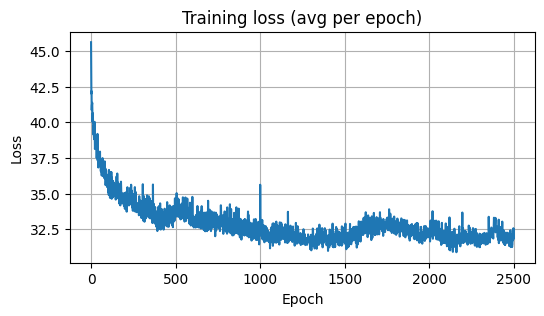

In [ ]:
# Cell 9: Evaluate on test set and get predictions
model.eval()
with torch.no_grad():
    test_loss, test_metrics = pinn_loss(model, X_test, y_test)
    out_test = model(X_test)
    pg_test_hat  = out_test["pg"].cpu().numpy()       # (N_test, num_gens)
    lambda_test  = out_test["lambda"].cpu().numpy()
    mu3_test     = out_test["mu3"].cpu().numpy()
    mu27_test    = out_test["mu27"].cpu().numpy()
    tau_test_hat = out_test["tau"].cpu().numpy()

print("\nTest metrics:")
for k,v in test_metrics.items():
    print(f"{k}: {v:.4e}")

plt.figure(figsize=(6,3))
plt.plot(history)
plt.title("Training loss (avg per epoch)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()


In [ ]:
# -----------------------------
# Tolerance settings
# -----------------------------
tolerance_percent = 1.0   # 1% tolerance for generators and lines
pb_tolerance = 1       # 1 MW tolerance for power balance

# Convert tolerances to absolute values
gen_tol  = pmax * (tolerance_percent / 100.0)       # tolerance per generator
line_tol = line_limits * (tolerance_percent / 100.0) # tolerance per line

# Convert normalized X_test to physical load values
X_test_phys_np = (X_test.cpu().numpy() * X_std.cpu().numpy()) + X_mean.cpu().numpy()
pred_pg = pg_test_hat.copy()  # predicted generator outputs (N_test, num_gens)

# -----------------------------
# A) Generator capacity violations
# -----------------------------
gen_violation_count = 0

for t in range(pred_pg.shape[0]):           # iterate over test samples
    for g in range(num_gens):               # iterate over generators
        if pred_pg[t, g] > pmax[g] + gen_tol[g]:
            gen_violation_count += 1

print(f"Total generator capacity violations (all generators, test set): {gen_violation_count}")

# -----------------------------
# B) Line flow violations
# -----------------------------
num_test = X_test_phys_np.shape[0]
flows_test = np.zeros((num_test, num_lines))

for t in range(num_test):
    load_vec = build_full_demand(torch.tensor(X_test_phys_np[t:t+1], device=device, dtype=torch.float32))
    gen_vec  = build_full_gen_injections(torch.tensor(pred_pg[t:t+1], device=device, dtype=torch.float32))
    inj = gen_vec - load_vec
    flows = (inj @ PTDF_t).cpu().numpy()
    flows_test[t, :] = flows[0]

line_violation_count = 0

for t in range(num_test):
    for l in range(num_lines):
        if flows_test[t, l] > line_limits[l] + line_tol[l] or flows_test[t, l] < -line_limits[l] - line_tol[l]:
            line_violation_count += 1

print(f"Total line flow violations (all lines, test set): {line_violation_count}")

# -----------------------------
# C) Power balance violations
# -----------------------------
pb_violation_count = 0

for t in range(num_test):
    total_gen = np.sum(pred_pg[t])
    total_load = np.sum(X_test_phys_np[t])
    if abs(total_gen - total_load) > pb_tolerance:
        pb_violation_count += 1

print(f"Total power balance violations (test set): {pb_violation_count}")


Total generator capacity violations (all generators, test set): 10
Total line flow violations (all lines, test set): 824
Total power balance violations (test set): 1935


In [ ]:

#  MW Violations

print("alpha_stat   =", alpha_stat)
print("alpha_cs     =", alpha_cs)
print("alpha_pf     =", alpha_pf)
print("alpha_df     =", alpha_df)



num_test = X_test_phys_np.shape[0]

# -----------------------------
# Generator capacity violations (MW)
# -----------------------------
gen_violation_MW = 0.0  # total MW violation
gen_violation_count = 0

for t in range(num_test):
    for g in range(num_gens):
        excess = pred_pg[t, g] - pmax[g]
        if excess > gen_tol[g]:
            gen_violation_MW += excess
            gen_violation_count += 1

avg_gen_violation_per_sample = gen_violation_MW / num_test

print(f"Generator capacity violation: total MW = {gen_violation_MW:.2f}, average MW/sample = {avg_gen_violation_per_sample:.2f}, count = {gen_violation_count}")

# -----------------------------
# Line flow violations (MW)
# -----------------------------
line_violation_MW = 0.0
line_violation_count = 0

for t in range(num_test):
    for l in range(num_lines):
        flow = flows_test[t, l]
        if flow > line_limits[l] + line_tol[l]:
            line_violation_MW += flow - line_limits[l]
            line_violation_count += 1
        elif flow < -line_limits[l] - line_tol[l]:
            line_violation_MW += -line_limits[l] - flow  # absolute MW violation
            line_violation_count += 1

avg_line_violation_per_sample = line_violation_MW / num_test

print(f"Line flow violation: total MW = {line_violation_MW:.2f}, average MW/sample = {avg_line_violation_per_sample:.2f}, count = {line_violation_count}")

# -----------------------------
# Power balance violations (MW)
# -----------------------------
pb_violation_MW = 0.0
pb_violation_count = 0

for t in range(num_test):
    total_gen = np.sum(pred_pg[t])
    total_load = np.sum(X_test_phys_np[t])
    mismatch = abs(total_gen - total_load)
    if mismatch > pb_tolerance:
        pb_violation_MW += mismatch
        pb_violation_count += 1

avg_pb_violation_per_sample = pb_violation_MW / num_test

print(f"Power balance violation: total MW = {pb_violation_MW:.2f}, average MW/sample = {avg_pb_violation_per_sample:.2f}, count = {pb_violation_count}")


alpha_stat   = 0.25
alpha_cs     = 0.25
alpha_pf     = 0.5
alpha_df     = 0.25
Generator capacity violation: total MW = 170.49, average MW/sample = 0.09, count = 10
Line flow violation: total MW = 15082.05, average MW/sample = 7.56, count = 824
Power balance violation: total MW = 40045.32, average MW/sample = 20.06, count = 1935


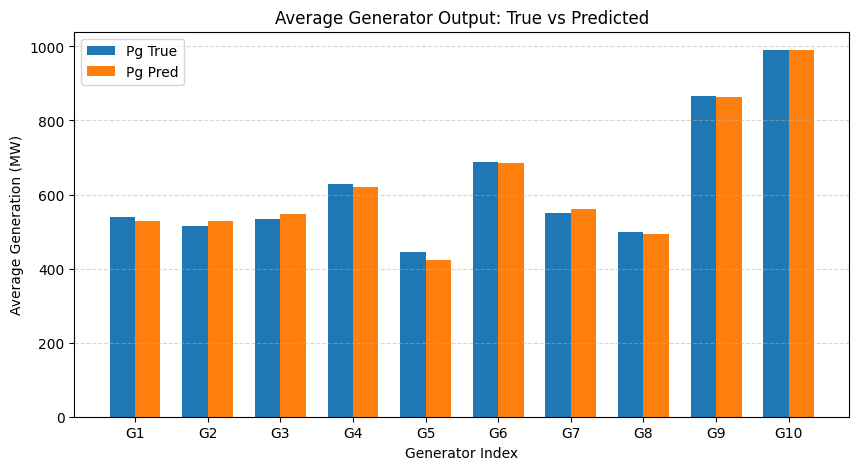

In [ ]:
# Compute average generation per generator across test dataset
avg_pg_true = np.mean(y_test_np[:, :num_gens], axis=0)   # (10,)
avg_pg_pred = np.mean(pg_test_hat, axis=0)               # (10,)

# Bar width and positions
import matplotlib.pyplot as plt
import numpy as np

gen_indices = np.arange(num_gens)
bar_width = 0.35

plt.figure(figsize=(10,5))
plt.bar(gen_indices - bar_width/2, avg_pg_true, width=bar_width, label='Pg True')
plt.bar(gen_indices + bar_width/2, avg_pg_pred, width=bar_width, label='Pg Pred')

plt.xlabel("Generator Index")
plt.ylabel("Average Generation (MW)")
plt.title("Average Generator Output: True vs Predicted")
plt.xticks(gen_indices, [f"G{i+1}" for i in gen_indices])
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()
